# HW3: Логистическая регрессия, оптимизация, подбор гиперпараметров.

## Ф.И.О: Проскуряков Иван Сергеевич

По вопросам в задании писать в беседу курса или в лс (tg: @Skorik_S)

## Задание 1: Теоретическая часть

Постановка задачи логистической регрессии:
$$
    \mathcal{L}(\theta, X, y) = \dfrac{1}{N}\sum_{i=1}^N\log(1 + e^{-y_i\langle\theta, x_i\rangle}) → \min_{θ \in \mathbb{R}^d}, \tag{1}
$$

в которой


1.   $θ \in \mathbb{R}^d$ -- вектор параметров модели.
2.   $(x_i, y_i)$ -- обучающая пара. В данной постановке $y = \{-1, 1\}$.



### Задача 0 (0.5 баллов)

1. *Получите постановку логистической регрессии, используя принцип максимума правдоподобия в предположении $y = \{0, 1\}$.*
2. Проверьте, что если метки классов $y = \{-1, 1\}$, то полученная постановка примет вид (1).
---

#### Ваше решение:

1. $\frac{1}{l} \sum\limits_{i=1}^{l}\left(log(1 + \exp(-<w, x_i>))^{\mathbb{I}[y_i=1]}\cdot (1 + \exp(<w, x_i>)^{\mathbb{I}[y_i=0]}) \right)$: при $y_i = 0$ в произведение входит правая скобка $(1 + \exp(<w, x_i>))$, при $y_i = 1$ в произведение входит левая скобка $(1 + \exp(-<w, x_i>))$ - заметим, что это обобщается в $1 + \exp(<w, x_i>(1 - 2y_i))$, тогда постановка задачи для классов ${0,1}$ будет 
$$
\frac{1}{l} \sum\limits_{i=1}^{l}log(1 + \exp(<w, x_i>(1 - 2y_i))) \rightarrow \min_{w \in \mathbb{R}^d}
$$

2. Очевидно, но для очистки совести: 

$\frac{1}{l} \sum\limits_{i=1}^{l}\left(log(1 + \exp(-<w, x_i>))^{\mathbb{I}[y_i=1]}\cdot (1 + \exp(<w, x_i>)^{\mathbb{I}[y_i=-1]}) \right)$, 

при $y_i = -1$ под логарифмом будет скобка $1 + e^{<w, x_i>} = 1 + e^{-y_i \cdot <w, x_i>}$, при $y_i = 1$ под логарифмом будет скобка $1 + e^{-<w, x_i>} = 1 + e^{-y_i \cdot <w, x_i>}$ - ч.т.д.

### Задача 1 (2 балла)

1. Покажите, что градиент функции потерь равен:

$$\nabla \mathcal{L}(\theta, X, y) = - \dfrac{1}{N}\sum_{i=1}^N \dfrac{y_i x_{i}e^{-y_i\langle\theta, x_i\rangle}}{1 + e^{-y_i\langle\theta, x_i\rangle}} $$

2. Покажите, что гессиан функции потерь равен:

$$ \nabla^2 \mathcal{L}(\theta, X, y) = \dfrac{1}{N}X^\top D X, \tag{2}$$
где $D$ -- диагональная матрица с элементами $\sigma(-y_i\langle\theta, x_i\rangle)(1 - \sigma(-y_i\langle\theta, x_i\rangle))$, где $\sigma(\cdot)$ -- функция сигмоиды

---

#### Ваше решение:

1. $\nabla_{\theta} \dfrac{1}{N}\sum_{i=1}^N\log(1 + e^{-y_i\langle\theta, x_i\rangle}) = \dfrac{1}{N}\sum_{i=1}^N \frac{d}{d \theta}\log(1 + e^{-y_i\langle\theta, x_i\rangle}) = \dfrac{1}{N}\sum_{i=1}^N \frac{\frac{d}{d \theta}(1 + e^{-y_i\langle\theta, x_i\rangle})}{(1 + e^{-y_i\langle\theta, x_i\rangle})}$, $\frac{d}{d \theta}(1 + e^{-y_i\langle\theta, x_i\rangle}) = \left(\frac{\partial (1 + e^{-y_i\langle\theta, x_i\rangle})}{\partial \theta_1}, \frac{\partial (1 + e^{-y_i\langle\theta, x_i\rangle})}{\partial \theta_2}, \cdots, \frac{\partial (1 + e^{-y_i\langle\theta, x_i\rangle})}{\partial \theta_d},\right)^T = -y_i x_i e^{-y_i\langle\theta, x_i\rangle}$, и теперь:

$$
\dfrac{1}{N}\sum_{i=1}^N \frac{\frac{d}{d \theta}(1 + e^{-y_i\langle\theta, x_i\rangle})}{(1 + e^{-y_i\langle\theta, x_i\rangle})} = \dfrac{1}{N}\sum_{i=1}^N \frac{-y_i x_i e^{-y_i\langle\theta, x_i\rangle}}{(1 + e^{-y_i\langle\theta, x_i\rangle})}
$$
Ч. т. д.

### Задача 2* (1 балл)

1. Покажите что в выражении (2) $\nabla^2\mathcal{L} \succeq 0$. Что это говорит об $\mathcal{L}$ и её экстремумах?

2. В каких случаях в выражении (2) $\nabla^2\mathcal{L} \succ 0$? Что в этом случае мы можем сказать о глобальном минимуме? Всегда ли он существует? Ответ обоснуйте.

---

#### Ваше решение:*

---

Регуляризируем исходную задачу:
$$
\mathcal{L}(\theta, X, y) = -\dfrac{1}{N}\sum_{i=1}^N\log(1 + e^{-y_i\langle\theta, x_i\rangle}) + \dfrac{\lambda}{2}\|\theta\|^2 → \min_{θ \in \mathbb{R}^d}, \tag{3}
$$
здесь $\lambda > 0$ -- параметр регуляризации. Задача (3) представляет собой *минимизацию эмпирического риска*

### Задача 3 (2 балла)

1. Покажите, что задача (3) L-гладкая с константой $$L = \dfrac{1}{4N}\lambda_{max}(XX^\top) + \lambda \tag{4}.$$

2. Покажите, что задача (3) $\mu$-сильно-выпуклая с константой $\mu = λ$.

Для доказательства п.1 и п.2 воспользуйтесь тем, что $L = \lambda_{max}(\nabla^2 \mathcal{L}(\theta, X, y))$ и $\mu = \lambda_{min}(\nabla^2 \mathcal{L}(\theta, X, y))$, где $\lambda_{max}(\cdot)$ и $\lambda_{min}(\cdot)$ -- максимальное и минимальное собственное значение матрицы.

---

#### Ваше решение:

1. $L$-гладкость значит, что $\forall \theta_1, \theta_2 ||\nabla L(\theta_1) - \nabla L(\theta_1)||_2 \leq L ||\theta_1 - \theta_2||_2$. В левой скобке имеем из доказанного ранее:
$$
\bigg|\bigg|\left(\dfrac{1}{N}\sum_{i=1}^N \dfrac{y_i x_{i}e^{-y_i\langle\theta_1, x_i\rangle}}{1 + e^{-y_i\langle\theta_1, x_i\rangle}} - \dfrac{y_i x_{i}e^{-y_i\langle\theta_2, x_i\rangle}}{1 + e^{-y_i\langle\theta_2, x_i\rangle}}\right) + \lambda (\theta_1 - \theta_2)\bigg|\bigg|_2 = \dfrac{1}{N}\bigg|\bigg| \sum_{i=1}^N y_i x_i \left(\sigma(-y_i\langle\theta_1, x_i\rangle) - \sigma(-y_i\langle\theta_2, x_i\rangle) \right)  + \lambda (\theta_1 - \theta_2) \bigg|\bigg|_2 \leq
$$

$$
\leq \dfrac{1}{N}\bigg|\bigg| \sum_{i=1}^N y_i x_i \left(\sigma(-y_i\langle\theta_1, x_i\rangle) - \sigma(-y_i\langle\theta_2, x_i\rangle) \right)\bigg|\bigg|_2  + \lambda\bigg|\bigg|(\theta_1 - \theta_2) \bigg|\bigg|_2
$$

### Задача 4* (1 балл)

1. Всегда ли существует глобальный минимум задачи (3)? Ответ обоснуйте.

#### Ваше решение:
У выпуклых функций стационарная точка - автоматически глобальная экстремаль (минимум или максимум). Задача (3) выпуклая. Соответственно, если есть стационарные точки, то глобальный минимум существует.

## Задание 2: Сравнение алгоритмов оптимизации

Для практической части мы пользуемся библиотекой `numpy`: [документация](https://numpy.org/doc/)

Не пользуйтесь другими библиотеками (`torch`, `jax` итп)

In [1]:
!pip install scikit-learn numpy matplotlib tqdm requests

  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached matplotlib-3.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.56.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (101 kB)
  Using cached kiwisolver-1.4.8-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pillow-11.1.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cach

In [2]:
from typing import Callable
import time
from functools import partial
from tqdm import tqdm
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import requests

Подготовим данные

In [11]:
url = 'https://drive.google.com/uc?id=1lgwawQxGD_6XruWbquMH6W2yKPVQ5kdi'
filename = 'mushrooms.txt'

response = requests.get(url)
with open(filename, 'wb') as file:
    file.write(response.content)

In [12]:
data = load_svmlight_file("./mushrooms.txt")
mushrooms_x, mushrooms_y = data[0].toarray(), data[1]
# сделаем y -1 или 1
mushrooms_y = 2 * mushrooms_y - 3

Разделим данные на train/test

**Важно:** не меняйте код ниже. random_state зафиксирован для воспроизводимости.

In [13]:
train_mush_x, test_mush_x, train_mush_y, test_mush_y = train_test_split(
    mushrooms_x, mushrooms_y, test_size=0.2, random_state=42
)

print(f"{train_mush_x.shape=}")
print(f"{train_mush_y.shape=}")

train_mush_x.shape=(6499, 112)
train_mush_y.shape=(6499,)


### Задача 0 (1 балл)

Найдите константу гладкости $L$ согласно (4) на практике для `train_mush_x`.

---

In [14]:
def get_lipschitz(x_values: np.ndarray) -> float:
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################    
    return ((max(np.linalg.eigvals(x_values @ np.transpose(x_values))) / (4 * x_values.shape[0])) / (1 - pow(10, -3))).real


In [76]:
get_lipschitz(train_mush_x)

np.float64(2.5872260889612666)

In [77]:
def assert_lipschitz(get_lipschitz: Callable) -> None:
    true_lipschitz = 2.5872260889612666
    your_lipschitz = get_lipschitz(train_mush_x)
    assert np.allclose(true_lipschitz, your_lipschitz, atol=1e-6), "Failed on get_lipschitz(train_mush_x)"
    print("Success!!!")

assert_lipschitz(get_lipschitz)

Success!!!


In [15]:
lipschitz_mush = get_lipschitz(train_mush_x)
lambda_mush = lipschitz_mush / 1000

### Задача 1 (1 балл)

Реализуйте посчет значения, градиента и гессиана целевой функции (3).

In [16]:
def mush_exp(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    # TODO: Calculate exp(-y * <w,x>)
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    return np.exp(-1.0 * y[:np.newaxis] * np.dot(x, w))


def mush_f(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> float:
    # TODO: Calculate loss function
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    exp_term = mush_exp(x, y, w)
    return 1 / x.shape[0] * np.sum(np.log(1 + exp_term)) + lambda_mush / 2 * np.sum(np.pow(w, 2))


def mush_grad(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: Calculate gradient of loss function
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    return -1 / x.shape[0] * np.sum(y[:, np.newaxis] * x * (mush_exp(x, y, w)[:,np.newaxis]  / (1 + mush_exp(x, y, w))[:,np.newaxis]), axis=0) + lambda_mush * w


def sigmoid(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
):
    return 1 / (1 + mush_exp(x, y, w))    

def mush_hess(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: Calculate hessian of loss function
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    D = np.diag(sigmoid(w, x, y) * (1 - sigmoid(w, x, y)))
    return 1 / x.shape[0] * np.transpose(x) @ D @ x + lambda_mush * np.eye(x.shape[1])


def mush_accuracy(
    w: np.ndarray, x: np.ndarray = test_mush_x, y: np.ndarray = test_mush_y
) -> float:
    if len(x) == 0:
        return 0
    return np.mean((np.sign(x @ w) == y))

In [17]:
def assert_mush(mush_f: Callable, mush_grad: Callable, mush_hess: Callable):
    w = np.zeros(train_mush_x[0].shape[0])
    assert np.allclose(mush_f(w), 0.6931471805599453, atol=1e-6), "Failed on mush_f(w) for w=0"
    assert np.allclose(mush_grad(w).sum(), -0.3732112632712724, atol=1e-6), "Failed on mush_grad(w) for w=0"
    assert np.allclose(mush_hess(w).sum(), 110.53976932196366, atol=1e-6), "Failed on mush_hess(w) for w=0"

    w = np.ones(train_mush_x[0].shape[0])
    assert np.allclose(mush_f(w), 10.271673398468815, atol=1e-6), "Failed on mush_f(w) for w=1"
    assert np.allclose(mush_grad(w).sum(), 10.416558042769106, atol=1e-6), "Failed on mush_grad(w) for w=1"
    assert np.allclose(mush_hess(w).sum(), 0.2897696563545762, atol=1e-6), "Failed on mush_hess(w) for w=1"
    print("Success!!!")

assert_mush(mush_f, mush_grad, mush_hess)

Success!!!


### Задача 2 (2 балла)

Рассмотрим и реализуем метод градиентного спуска (Gradient Descent)

$$
\begin{equation*}
w_{k+1} = w_k - \gamma_k \nabla \mathcal{L}(w_k)
\end{equation*}
$$

In [18]:
# Фиксируем рандомизацию для воспроизводимости
seed = 42
np.random.seed(seed)
start_w_mush = np.random.randn(train_mush_x.shape[1])

In [19]:
# Базовый класс оптимизатора
class ManualSolver:
    def __init__(
        self,
        lr: float | Callable, # Скорость обучения
        name: str, # Название оптимизатора (для логгирования)
        first_order: bool, # Использует ли оптимизатор grad_f
        second_order: bool, # Использует ли оптимизатор hess_f
    ) -> None:
        super().__init__()
        self.name = name
        self.lr = lr if isinstance(lr, Callable) else lambda _: lr
        self.first_order = first_order
        self.second_order = second_order

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: np.ndarray) -> np.ndarray:
        # эту функцию должны переопределить наследуемые классы
        raise NotImplementedError

#### Задача 2.1

Реализуйте шаг обучения и тестирования.

**Важно:** критерием сходимости является отношение $\frac{\| \nabla f(w^k) \|}{\| \nabla f(w^0) \|}$ на **обучающей** выборке. В связи с этим, подсчет `grad_norm`$=\| \nabla f(w^k) \|$ необходимо производить на обучающей выборке `train_mush_x`.

Подсчет точности и лосса в `eval_optimizer_step` проводятся на тестовой выборке.

In [20]:
def train_optimizer_step(
    optimizer: ManualSolver,
    w: np.ndarray,
    iter_num: int,
    x: np.ndarray = train_mush_x,
    y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: implement train_step pipeline;
    # OUTPUT: Updated training weights
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    if optimizer.second_order:
        h = mush_hess(w, x, y)
    else:
        h = None
    return optimizer.step(w, iter_num, mush_grad(w, x, y), h)
    

In [21]:
def eval_optimizer_step(
    w: np.ndarray,
    x: np.ndarray = test_mush_x,
    y: np.ndarray = test_mush_y
) -> list[float, float, float]:
    # TODO: implement eval pipeline;
    # OUTPUT: [grad_norm, accuracy, val_loss]
    # You need to calculate `grad_norm` on train_mush_x!!
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    global train_mush_x, train_mush_y
    # train_mush_x = train_mush_x # here is a global variable
    # train_mush_y = train_mush_y
    grad_norm = np.sqrt(np.sum(np.pow(mush_grad(w, train_mush_x, train_mush_y), 2)))
    accuracy = mush_accuracy(w, x, y)
    val_loss = mush_f(w, x, y)
    return [grad_norm, accuracy, val_loss]

In [22]:
def test_optimizer(
    optimizer: ManualSolver,
    max_iters: int = 1000,
    start_w: np.ndarray = start_w_mush,
    stop_criterion: float = 1e-8,
) -> dict:

    accuracies = []
    losses = []
    criterion_logs = []  # нормы градиента или что-то другое
    time_logs = []

    w = start_w.copy()

    # initial eval
    start_grad_norm, accuracy, val_loss = eval_optimizer_step(w)
    time_logs.append(0)
    criterion_logs.append(start_grad_norm / start_grad_norm)
    accuracies.append(accuracy)
    losses.append(val_loss)

    start_time = time.time()

    with tqdm(range(max_iters), desc=optimizer.name) as loop:
        for k in loop:
            # train
            w = train_optimizer_step(optimizer, w, k)
            # eval
            grad_norm, accuracy, val_loss = eval_optimizer_step(w)
            criterion_logs.append(grad_norm / start_grad_norm)
            accuracies.append(accuracy)
            losses.append(val_loss)
            time_logs.append(time.time() - start_time)
            loop.set_postfix(
                {"Loss": val_loss, "Accuracy": accuracy, "Grad norm": grad_norm / start_grad_norm}
            )
            # Остановить, если criterion <= stop_criterion
            if grad_norm / start_grad_norm <= stop_criterion:
                break

    results_dict = {
        "name": optimizer.name,
        "num_iters": list(range(len(accuracies))),
        "Time": time_logs,
        "Accuracy": accuracies,
        "Criterion": criterion_logs,
        "Loss": losses,
        "W": w.copy(),
    }

    return results_dict

In [23]:
def plot_results(results_dictionaries: list, title: str, metrics_type: list = ['Criterion'], x: str = 'num_iters') -> None:
    valid_metrics = {'Criterion', 'Accuracy', 'Loss'}
    assert all(metric in valid_metrics for metric in metrics_type), \
        f"All metrics should be one of {valid_metrics}, got {metrics_type}"

    assert x in ['num_iters', 'Time'], f"x should be one of ['num_iters', 'Time'], got {x}"

    num_metrics = len(metrics_type)
    if num_metrics == 1:
        width = 10
    else:
        width = 6 * num_metrics
    fig, axs = plt.subplots(1, num_metrics, figsize=(width, 6), sharey=False)
    if num_metrics == 1:
        axs = [axs]

    for idx, metric_type in enumerate(metrics_type):
        ax = axs[idx]
        for results_dict in results_dictionaries:
            if metric_type == 'Criterion':
                ax.set_yscale('log')
            ax.plot(
                results_dict[x],
                results_dict[metric_type],
                label=results_dict["name"],
                linewidth=2
            )
        ylabel = f"log {metric_type}" if metric_type == 'Criterion' else metric_type
        ax.set_xlabel(x, fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.legend(loc='best', fontsize=12)
        ax.grid(True)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Задача 2.2

- Реализуйте метод шаг градиентного спуска (х баллов)
- Проведите оптимизацию гиперпараметров . Сравнения проиллюстрируйте на графике. Критерием задачи является $\frac{\| \nabla f(w^k) \|}{\| \nabla f(w^0) \|}$. Однако приветствуются также графики точности и функции потерь на тесте (x баллов):
1.  Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $s \in [0, 3]$, $L$ -- константа липшица в задаче. Рассмотрите не менее 4-х $s$;
2. Протестируйте различные $\gamma_k = \frac{\gamma}{\delta + k}$, где $\gamma, \delta \in [1, 100]$. Рассмотрите не менее 4-х гиперпараметров;
3. Протестируйте различные $\gamma_k = \frac{\gamma}{\delta + \sqrt{k}}$, где $\gamma, \delta \in [1, 100]$. Рассмотрите не менее 4-х гиперпараметров;
4. Выберите лучшие $\gamma^1_k$, $\gamma^2_k$, $\gamma^3_k$ из п. 1-3 соответственно. Сделайте общий график, сравнивающий их. Также добавьте базовый $\gamma_k = \gamma = 10^{-3}$

In [117]:
class GradientDescent(ManualSolver):
    def __init__(self, lr, name) -> None:
        super().__init__(lr, name, True, False)
    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: None) -> np.ndarray:
        # TODO: init GradientDescent step
        # YOUR CODE HERE:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        g = self.lr(k)
        new_w = w - g * grad_f
        return new_w


GD lr=1e-3:   0%|          | 0/1000 [00:00<?, ?it/s]

GD lr=1e-3: 100%|██████████| 1000/1000 [00:35<00:00, 27.87it/s, Loss=1.12, Accuracy=0.66, Grad norm=0.47] 


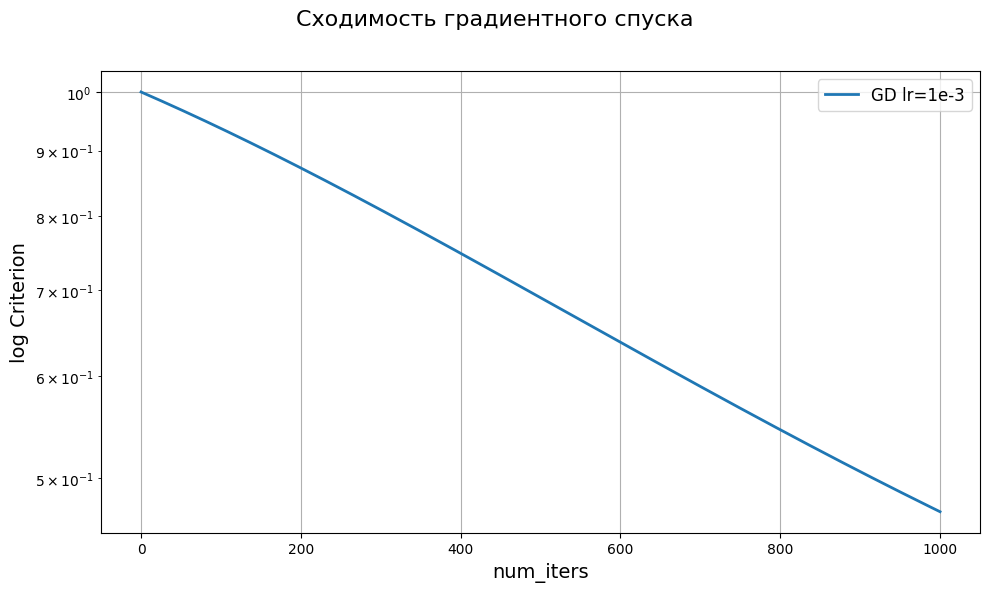

In [135]:
grad_opt = GradientDescent(lr=1e-3, name='GD lr=1e-3')
gd_res_baseline = test_optimizer(grad_opt)
plot_results([gd_res_baseline], 'Cходимость градиентного спуска')

In [140]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
def first_step_kind(s: float, l: float = lipschitz_mush) -> np.float128:
    return lambda _: s / l

In [137]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

def second_step_kind(iter: int, gamma: float = 1, delta: float = 1) -> float:
    return gamma / (delta + iter)

def dynamic_lr(initial_gamma, delta):
    # TODO: return a lambda function that depends on k
    return lambda iter: second_step_kind(iter, initial_gamma, delta)

In [138]:
3.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
def third_step_kind(iter: int, gamma: float = 1, delta: float = 1) -> float:
    return gamma / (delta + np.sqrt(iter))

def dynamic_lr_sqrt(initial_gamma, delta):
    # TODO: return a lambda function that depends on √k
    return lambda iter: third_step_kind(iter, initial_gamma, delta)

```bash
s = 2.5: 100%|██████████| 1000/1000 [00:22<00:00, 44.70it/s, Loss=0.0837, Accuracy=0.996, Grad norm=0.00102]

s = 1: 100%|██████████| 1000/1000 [00:22<00:00, 45.22it/s, Loss=0.0926, Accuracy=0.994, Grad norm=0.00553]

s = 1.5: 100%|██████████| 1000/1000 [00:22<00:00, 44.40it/s, Loss=0.0864, Accuracy=0.996, Grad norm=0.00306]

s = 3: 100%|██████████| 1000/1000 [00:22<00:00, 43.56it/s, Loss=0.0835, Accuracy=0.996, Grad norm=0.000599]
```
Кажется, что при максимальном s у нас лучшие результаты, но при этом норма градиента очень маленькая - это мне не нравится. Если говорить о реальной жизни, я бы остановился на $2.5$.

GD s/L, s = 3:   0%|          | 0/1000 [00:00<?, ?it/s]

GD s/L, s = 3: 100%|██████████| 1000/1000 [00:22<00:00, 43.56it/s, Loss=0.0835, Accuracy=0.996, Grad norm=0.000599]


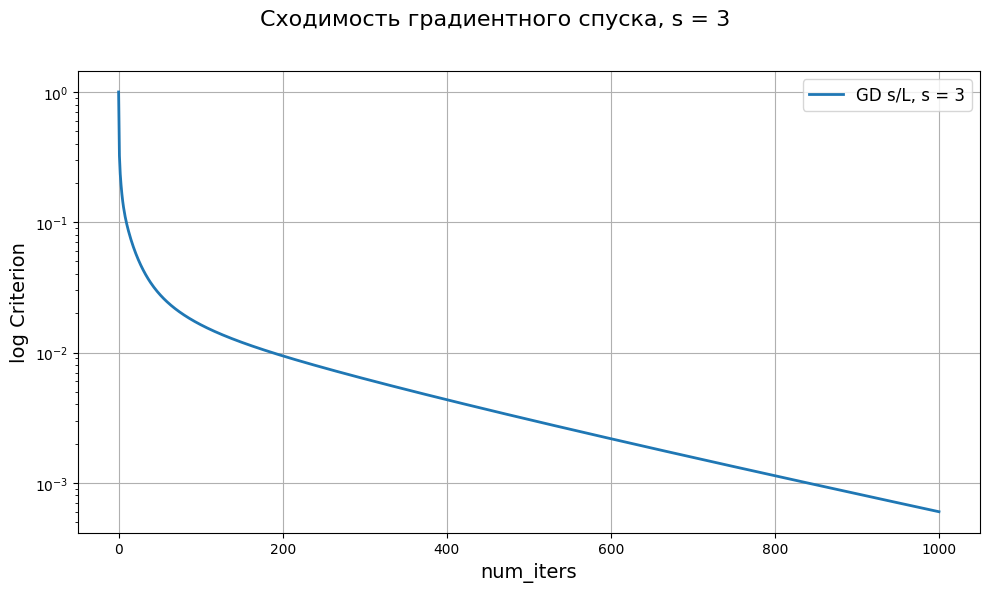

In [155]:
4.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
s = 3
grad_opt_const = GradientDescent(lr = first_step_kind(s), name=f"GD s/L, s = {s}")
gd_res_const = test_optimizer(grad_opt_const)
plot_results([gd_res_const], f'Сходимость градиентного спуска, s = {s}')

GD s/L, s = 0.1: 100%|██████████| 1000/1000 [00:23<00:00, 42.43it/s, Loss=0.229, Accuracy=0.948, Grad norm=0.0399]


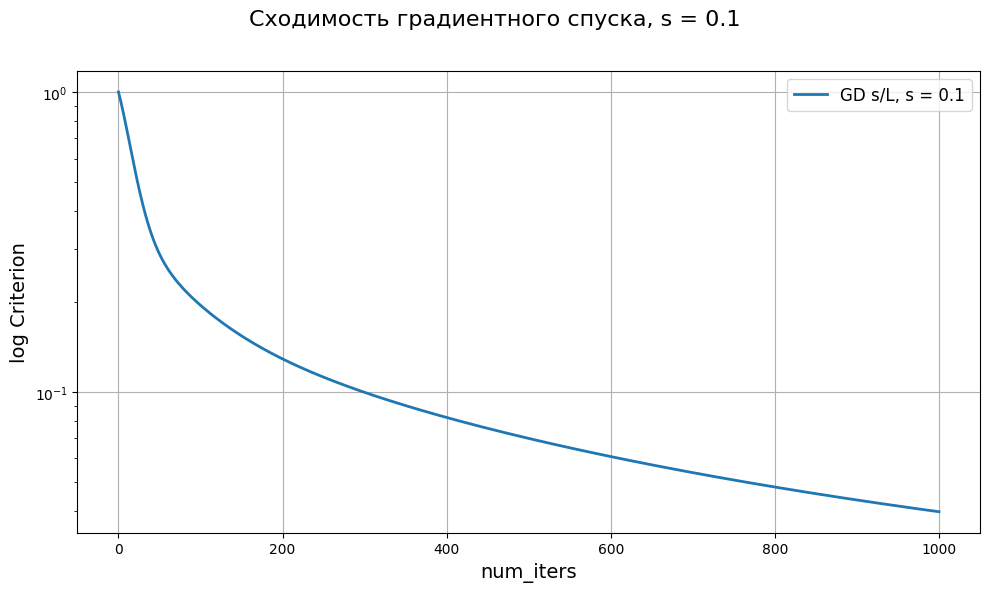

In [143]:
4.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
s = 0.1
grad_opt_const = GradientDescent(lr = first_step_kind(s), name=f"GD s/L, s = {s}")
gd_res_const = test_optimizer(grad_opt_const)
plot_results([gd_res_const], f'Сходимость градиентного спуска, s = {s}')

GD gamma-delta, gamma = 90, delta = 5:   0%|          | 0/1000 [00:00<?, ?it/s, Loss=1.02, Accuracy=0.912, Grad norm=0.0857]

GD gamma-delta, gamma = 90, delta = 5: 100%|██████████| 1000/1000 [00:22<00:00, 43.73it/s, Loss=0.0991, Accuracy=0.997, Grad norm=0.00925]


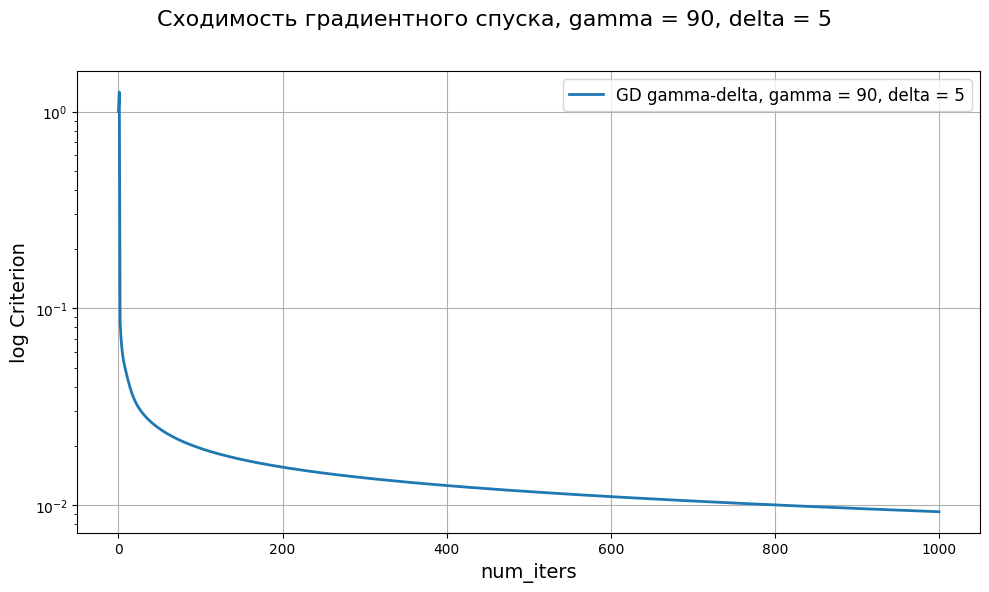

In [184]:
4.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
gamma = 90
delta = 5
grad_opt_by_iter = GradientDescent(lr = dynamic_lr(gamma, delta), name=f"GD gamma-delta, gamma = {gamma}, delta = {delta}")
gd_res_by_iter = test_optimizer(grad_opt_by_iter)
plot_results([gd_res_by_iter], f'Сходимость градиентного спуска, gamma = {gamma}, delta = {delta}')

```bash
gamma = 10, delta = 100: 100%|██████████| 1000/1000 [00:23<00:00, 43.12it/s, Loss=0.295, Accuracy=0.92, Grad norm=0.0592]

gamma = 90, delta = 5: 100%|██████████| 1000/1000 [00:22<00:00, 43.62it/s, Loss=0.0991, Accuracy=0.997, Grad norm=0.00925]

gamma = 100, delta = 5: 100%|██████████| 1000/1000 [00:24<00:00, 41.02it/s, Loss=0.0958, Accuracy=0.997, Grad norm=0.00841]

gamma = 100, delta = 10: 100%|██████████| 1000/1000 [00:22<00:00, 45.10it/s, Loss=0.0918, Accuracy=0.996, Grad norm=0.00592]

gamma = 80, delta = 10: 100%|██████████| 1000/1000 [00:22<00:00, 44.89it/s, Loss=0.0972, Accuracy=0.995, Grad norm=0.00756]

gamma = 80, delta = 1: 100%|██████████| 1000/1000 [00:22<00:00, 44.06it/s, Loss=0.352, Accuracy=0.985, Grad norm=0.0322]
```

Здесь лучший результаты при $\delta = 5$ и $\gamma = 100$ и $\delta = 5$ и $\gamma = 90$ - но результат не сильно лучше чем при константном шаге

GD gamma-delta-sqrt, gamma = 80, delta = 30:   0%|          | 0/1000 [00:00<?, ?it/s, Loss=1.18, Accuracy=0.671, Grad norm=0.744]

GD gamma-delta-sqrt, gamma = 80, delta = 30: 100%|██████████| 1000/1000 [00:20<00:00, 47.69it/s, Loss=0.0834, Accuracy=0.996, Grad norm=0.000181]


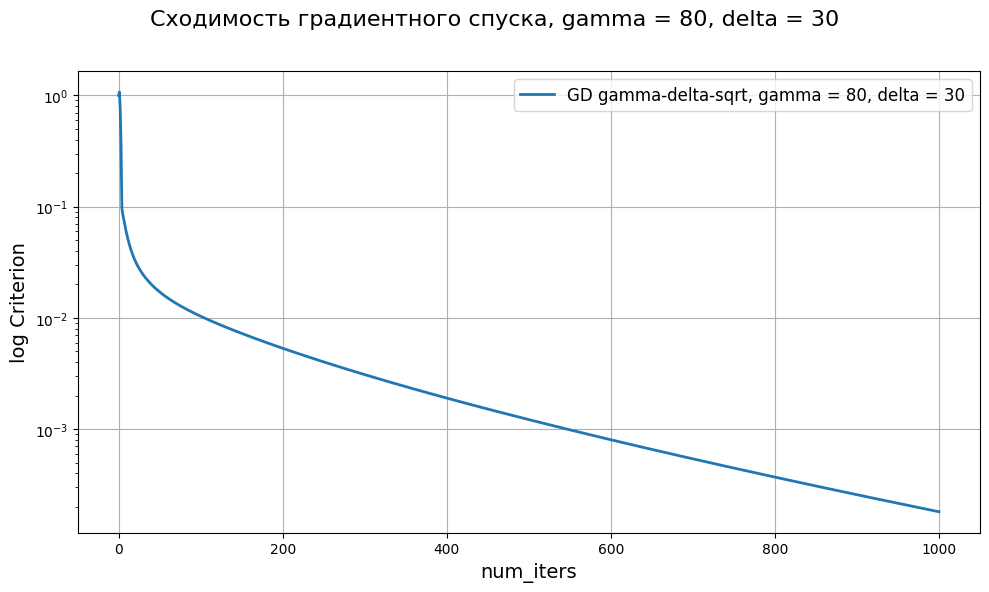

In [183]:
gamma = 80
delta = 30
grad_opt_by_iter_sqrt = GradientDescent(lr = dynamic_lr_sqrt(gamma, delta), name=f"GD gamma-delta-sqrt, gamma = {gamma}, delta = {delta}")
gd_res_by_iter_sqrt = test_optimizer(grad_opt_by_iter_sqrt)
plot_results([gd_res_by_iter_sqrt], f'Сходимость градиентного спуска, gamma = {gamma}, delta = {delta}')

```bash
gamma = 80, delta = 30: 100%|██████████| 1000/1000 [00:20<00:00, 47.69it/s, Loss=0.0834, Accuracy=0.996, Grad norm=0.000181]
```
Лушчего сочитания acc и loss получить этим методом не удалось

In [185]:
best_final_gd_res = gd_res_by_iter

### Задача 3 (1 балл)

Рассмотрим метод тяжёлого шарика (Heavy Ball)

$$ w^{k+1} = w^k - \gamma_k \nabla \mathcal{L}(w^k) + \tau_k (w^k - w^{k-1}) $$

- Реализуйте шаг метода тяжёлого шарика
- Используйте шаг $\gamma = \frac{1}{L}$.
1. Рассмотрите моментум  $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности: $s \cdot \tau$, где $s \in [0.9, 1.1]$. Рассмотрите не менее 3-х окрестностей.
2. Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации),
3. Сравните полученные результаты

In [24]:
class HeavyBall(ManualSolver):
    def __init__(self, lr, beta, init_w, name) -> None:
        super().__init__(lr, name, True, False)
        self.beta = beta if isinstance(beta, Callable) else lambda _: beta
        self.w_prev = init_w

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: None) -> np.ndarray:
        # TODO: implement heavy ball iteration step
        # YOUR CODE HERE:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        new_w = w - self.lr(k) * grad_f + self.beta(k) * (w - self.w_prev)
        self.w_prev = w
        return new_w

Momentum с интересной дробью, s = 1.05:   0%|          | 0/1000 [00:00<?, ?it/s]

Momentum с интересной дробью, s = 1.05: 100%|██████████| 1000/1000 [00:27<00:00, 36.22it/s, Loss=0.0835, Accuracy=0.997, Grad norm=0.000986]


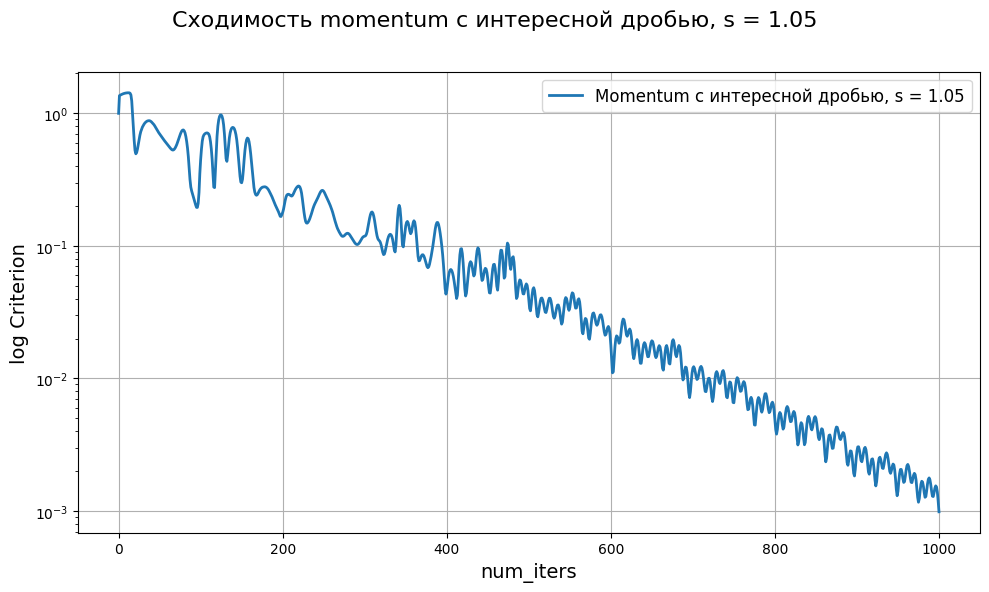

In [31]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
def parametrized_tau(s: float):
    mu = 0.001 * lipschitz_mush
    return lambda _: s * (np.sqrt(lipschitz_mush) - np.sqrt(mu)) / (np.sqrt(lipschitz_mush) + np.sqrt(mu))

s = 1.05
gd_momentum = HeavyBall(lr = 1 / lipschitz_mush, beta = parametrized_tau(s), init_w=np.ones(mushrooms_x.shape[1]), name=f"Momentum с интересной дробью, s = {s}")
gd_res_momentum = test_optimizer(gd_momentum)
plot_results([gd_res_momentum], f"Сходимость momentum с интересной дробью, s = {s}")

```bash
Momentum с интересной дробью, s = 0.97: 100%|██████████| 1000/1000 [00:24<00:00, 40.97it/s, Loss=0.0834, Accuracy=0.996, Grad norm=6.42e-7]

Momentum с интересной дробью, s = 1:  62%|██████▏   | 624/1000 [00:16<00:10, 36.72it/s, Loss=0.0834, Accuracy=0.996, Grad norm=9.48e-9] 

Momentum с интересной дробью, s = 0.909: 100%|██████████| 1000/1000 [00:26<00:00, 37.83it/s, Loss=0.0834, Accuracy=0.996, Grad norm=0.000107]

Momentum с интересной дробью, s = 1.05: 100%|██████████| 1000/1000 [00:27<00:00, 36.22it/s, Loss=0.0835, Accuracy=0.997, Grad norm=0.000986]
```
Кажется, что $s=1$ наиболее приятная, т.к. сходимость очень быстрая при малой разнице в acc

In [32]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

def beta_k_s(s):
    # TODO: return a lambda function that depends on k
    return lambda k: k / (k + s)

Momentum с итерационной дробью, s = 3: 100%|██████████| 1000/1000 [00:25<00:00, 38.63it/s, Loss=0.0834, Accuracy=0.996, Grad norm=0.000123]


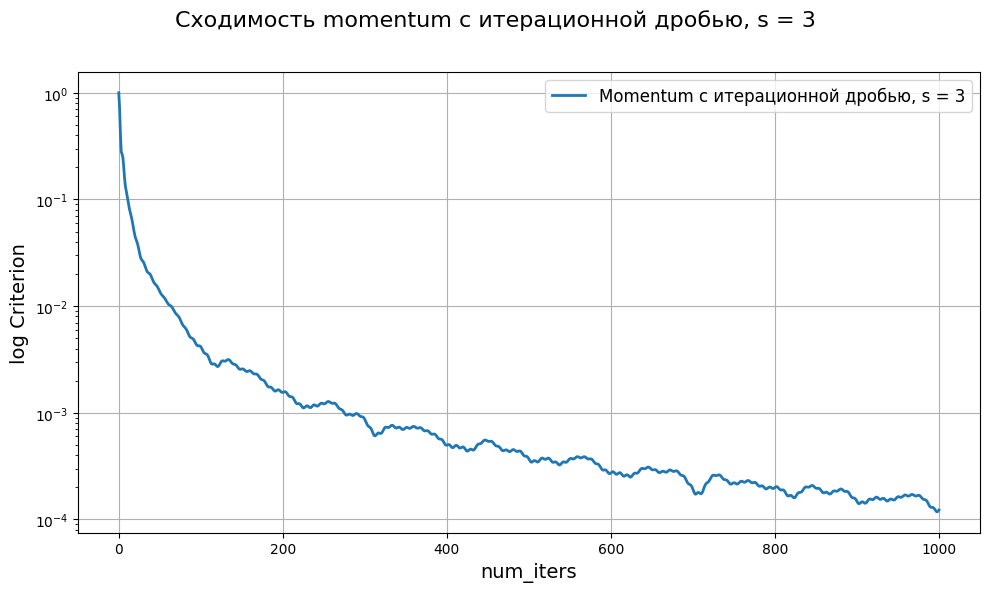

In [37]:
3.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
s = 3
gd_momentum_simple = HeavyBall(lr = 1 / lipschitz_mush, beta = beta_k_s(s), init_w=np.ones(mushrooms_x.shape[1]), name=f"Momentum с итерационной дробью, s = {s}")
gd_res_momentum_simple = test_optimizer(gd_momentum_simple)
plot_results([gd_res_momentum_simple], f"Сходимость momentum с итерационной дробью, s = {s}")

```bash
Momentum с итерационной дробью, s = 2: 100%|██████████| 1000/1000 [00:15<00:00, 63.93it/s, Loss=0.0833, Accuracy=0.996, Grad norm=0.000748]

Momentum с итерационной дробью, s = 1: 100%|██████████| 1000/1000 [00:16<00:00, 62.39it/s, Loss=0.0854, Accuracy=0.996, Grad norm=0.00881]

Momentum с итерационной дробью, s = 3: 100%|██████████| 1000/1000 [00:25<00:00, 38.63it/s, Loss=0.0834, Accuracy=0.996, Grad norm=0.000123]
```
Для $s=3$ график выглядит лучше всего - меньше колебаний с "отскоками". 

In [38]:
best_final_hb_res = gd_res_momentum_simple

### Задача 4 (1 балл)

Рассмотрим ускоренный градиентный метод (Nesterov Accelerated Gradient)

$$
\begin{align*}
& w_{k+1} = y_k - \gamma_k \nabla \mathcal{L}(y_k) \\
& y_{k+1} = w_{k+1} + \tau_k (w_{k+1} - w_k)
\end{align*}
$$

- Реализуйте шаг ускоренного градиентного метода
- Используйте шаг $\gamma = \frac{1}{L}$.
1. Рассмотрите моментум  $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности: $s \cdot \tau$, где $s \in [0.9, 1.1]$. Рассмотрите не менее 3-х окрестностей.
2. Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации).
3. Сравните полученные результаты.

In [ ]:
class NAG(ManualSolver):
    def __init__(self, lr, beta, init_w, name) -> None:
        super().__init__(lr, name, False, False)
        self.beta = beta if isinstance(beta, Callable) else lambda _: beta
        self.w_prev = init_w
        self.y_prev = init_w

    def step(self, w: np.ndarray, k: int, grad_f: None, hess_f: None) -> np.ndarray:
        # TODO: implement NAG iteration step
        # YOUR CODE HERE:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        pass

In [ ]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

def beta_k_s(s):
    # TODO: return a lambda function that depends on k
    pass

In [ ]:
3.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
best_final_nag_res = # put best output here

### Задача 5 (1 балл)

Рассмотрим один из самых известных методов второго порядка - Метод Ньютона (Newton's method):

$$
w_{k+1} = w_k - \nabla^2\mathcal{L}(w^k)^{-1} \nabla \mathcal{L}(w^k)
$$

А точнее, его модификацию - демпфированный метод Ньютона (Dumped Newton's method):

$$
w_{k+1} = w_k - \gamma_k \nabla^2\mathcal{L}(w^k)^{-1} \nabla \mathcal{L}(w^k)
$$

- Реализуйте шаг демпфированного метода Ньютона
1.  Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $s \in [0.5, 1.5]$, $L$ -- константа липшица в задаче. Рассмотрите не менее 3-х $s$.
2. Сравните полученные результаты.

In [ ]:
class Newton(ManualSolver):
    def __init__(self, lr, name) -> None:
        super().__init__(lr, name, True, True)

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: np.ndarray) -> np.ndarray:
        # TODO: implement Newton iteration step
        # YOUR CODE HERE:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        pass

In [ ]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
best_final_newton_res = # put best output here

### Сравнение лучших реализаций

In [ ]:
final_results = [best_final_gd_res, best_final_hb_res, best_final_nag_res, best_final_newton_res]
plot_results(final_results, 'Сравнение лучших реализаций методов', metrics_type=['Criterion'])

In [ ]:
final_results = [best_final_gd_res, best_final_hb_res, best_final_nag_res, best_final_newton_res]
plot_results(final_results, 'Сравнение лучших реализаций методов', metrics_type=['Criterion'], x='Time')

### Ваши выводы (до 0.5 баллов):

1. Почему предложено выбирать $\gamma = \frac{s}{L}$, $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$?
2. Почему наблюдаются различия в графиках по количеству итераций и по времени?
3. Любые другие рассуждения приветствуются

### Задача 6* (1 балл)

Метод проксимального градиентного спуска используется для оптмизации композитной функции потерь
$$
h(w) = f(w) + g(w),
$$
где $f(w)$ является выпуклой дифференцируемой функцией на своей области определения. Особенностью является то, что $g(w)$ не обязательно должна быть дифференцируема всюду на своём множестве определения.  

Мы решаем задачу вида
$$
\min_{w\in \mathbb{R}^d}\{f(w) + R(w)\},
$$
где $R(w)$ -- выпуклый (возможно негладкий) регуляризатор. \\
Обновление параметров осуществляется по схеме
$$
w_{k+1} = prox_{\gamma R}(w_k - \gamma\nabla f(w)),
$$
где проксимальный оператор определяется как
$$
prox_{\gamma R}(v) = \arg\min_{w\in \mathbb{R}^d}\left\{\dfrac{1}{2\gamma}\|w - v\|^2 + R(w) \right\}.
$$

* Реализуйте шаг проксимального градиентного спуска для различных видов $R(w)$ (L1, L2-регуляризация).
1. Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $L$ определяется согласно $R(w)$.
2. Сравните полученные результаты



In [ ]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

## Задание 3: Предсказание погоды в Австралии

Датасет содержит ежедневные наблюдения погоды в различных регионах Австралии за период в 10 лет.

Предсказываемым признаком является `RainTomorrow`: "Будет ли завтра дождь?". Это задача бинарной классификации.

Скачиваем датасет

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
url = 'https://huggingface.co/Anm5/rainpred/resolve/main/weatherAUS.csv'
filename = 'weatherAUS.csv'

response = requests.get(url)
with open(filename, 'wb') as file:
    file.write(response.content)
df = pd.read_csv(filename)
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Задача 1 (3 балла): Анализ датасета

Датасет представляет собой табличные данные. В этом задании вы убедитесь, что основной объём работы в классификации таких данных с помощью методов машинного состоит в анализе датасета и его признаков.

Давайте выведем общую информацию о признаках в датасете

In [ ]:
df.info()
print(f"Number of NaN targets: {df['RainTomorrow'].isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Можно заметить, что для некоторых примеров в датасете отсутствует разметка. Поскольку мы решаем задачу классификации с учителем, эти примеры нас не интересуют.

**Удалите из датасета сэмплы с отсутствующим значением `RainTomorrow`**.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
# Output: `df` variable.

Выделим категориальные переменные

In [ ]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('The categorical variables are :', categorical)
for feature in categorical:
    print(f"Number of unique {feature}:", df[feature].nunique())

The categorical variables are : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Number of unique Date: 3436
Number of unique Location: 49
Number of unique WindGustDir: 16
Number of unique WindDir9am: 16
Number of unique WindDir3pm: 16
Number of unique RainToday: 2
Number of unique RainTomorrow: 2


`RainTomorrow` является целевым признаком. `RainToday` нетрудно бинаризовать. Остальные признаки содержат большое количество значений.

В первом приближении, удалим признаки кроме `RainTomorrow`, `RainToday`. \\
**Важно:** датасет без категориальных признаков необходимо записать в отдельную переменную `df_numerical`. Исходный набор `df` пригодится в дополнительном задании. \\
**Бинаризуйте признаки `RainTomorrow`, `RainToday`. Остальные удалите**

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
# Output: `df_numerical` variable.

Перейдём к численным признакам

In [ ]:
numerical = [var for var in df.columns if df[var].dtype!='O']
round(df_numerical[numerical].describe(), 2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,141556.00,141871.00,140787.00,81350.00,74377.00,132923.00,140845.00,139563.00,140419.00,138583.00,128179.00,128212.00,88536.00,85099.00,141289.00,139467.00,140787.00,142193.00
mean,12.19,23.23,2.35,5.47,7.62,39.98,14.00,18.64,68.84,51.48,1017.65,1015.26,4.44,4.50,16.99,21.69,0.22,0.22
std,6.40,7.12,8.47,4.19,3.78,13.59,8.89,8.80,19.05,20.80,7.11,7.04,2.89,2.72,6.49,6.94,0.42,0.42
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40,0.00,0.00
25%,7.60,17.90,0.00,2.60,4.90,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60,0.00,0.00
50%,12.00,22.60,0.00,4.80,8.50,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10,0.00,0.00
75%,16.80,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40,0.00,0.00
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70,1.00,1.00


Одним из важных аспектов обработки численных признаков является *опеределние выбросов (англ. outliers)*. С одной стороны, выбросы можно выделить для всех признаков. Однако, бывает полезно изучить, для каких фичей они более характерны. Это позволит избежать потери важной информации.

**Вам необходимо определить, для каких из численных признаков имеет смысл выделять выбросы.** \\
**Примечание:** Это можно сделать с помощью графика гистограммы. Отрисуйте зависимости всех числовых признаков от целевого `RainTomorrow`. По оси x отложите значения признака, по оси y -- плотность `RainTomorrow` (в результате на рисунке будут 2 графика для каждого из бинарных значений). Для этого воспользуйтесь функцией `seaborn.histplot` с аргументом `stat='density'`. По виду графика можно интерпретировать, для каких признаков существуют значительные выбросы.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

Графики признаков с выбросами имеют характерное *смещение (англ. skew)*. Для смещённых распределений, выбросы можно определить через *межквартильное расстояние (англ. Interquartile Range).*
$$
IQR = Q3 - Q1,
$$
где $Q3$ -- третий квартиль, соответствующий порогу $75\%$, $Q1$ -- первый квартиль, соответствующий порогу $25\%$.

Тогда выбросы определяют согласно правилу:
*  *Нижний выброс* -- $x < Q1 - 1.5\cdot IQR$, $x$ -- значение признака;
*  *Верхний выброс* -- $x > Q3 + 1.5\cdot IQR$.

Если в результате получилось слишком много выбросов, значение $1.5$ можно увеличить, выделяя более "явные".

**Для полученных числовых признаков выделите соответствующие выбросы с помощью $IQR$ с коэффициентом 2**.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
# Output: `outliers` variable.

Есть 2 стратегии работы с выбросами:
*   Удалить соответствующий сэмпл;
*   Заменить его на среднее/медиану.

В первом приближении, удалим соответствующие примеры.

In [ ]:
df_num_no_outliers = df_numerical[~outliers.any(axis=1)].reset_index(drop=True)

Базовый анализ датасета почти закончен! Осталось пара шагов 🤗 \\
Выделим целевой признак в соответствующую переменную. Посмотрим на пропуски в обучающей выборке.

In [ ]:
X = df_num_no_outliers.drop(['RainTomorrow'], axis=1)
y = df_num_no_outliers['RainTomorrow']
X.isnull().sum()

,0
MinTemp,520
MaxTemp,248
Rainfall,1399
Evaporation,44504
Sunshine,49866
WindGustSpeed,6403
WindSpeed9am,1064
WindSpeed3pm,1832
Humidity9am,1235
Humidity3pm,2515


Пропуски необходимо заполнить. Обычно это делают с помощью среднего/медианы. Мы воспользуемся медианой, так как она более устойчива к выбросам.

**Заполните пропуски в обучающей выборке медианой.**

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

Наконец, осталось провести нормализацию значений.

Разделим выборку на обучающую и тестовую, чтобы не учитывать масштаб на тесте.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
count,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.000000,82989.0
mean,12.005008,24.312870,0.031507,5.652672,8.907943,38.557990,13.411054,18.147718,64.622613,46.590886,1018.424232,1015.642876,3.905855,4.005013,17.433884,22.763413,0.0
std,6.499165,7.014392,0.090510,2.690657,2.584452,12.215054,8.500710,8.418189,18.654949,19.366492,6.357521,6.371438,2.245767,2.093756,6.549522,6.765502,0.0
min,-8.200000,-2.700000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,985.100000,980.200000,0.000000,0.000000,-5.300000,-3.100000,0.0
25%,7.300000,19.100000,0.000000,4.800000,9.300000,31.000000,7.000000,13.000000,53.000000,32.000000,1014.400000,1011.500000,2.000000,3.000000,12.800000,17.900000,0.0
50%,11.900000,23.900000,0.000000,5.400000,9.400000,37.000000,13.000000,17.000000,66.000000,47.000000,1018.300000,1015.500000,4.000000,4.000000,17.300000,22.300000,0.0
75%,16.700000,29.300000,0.000000,6.000000,9.600000,44.000000,19.000000,24.000000,77.000000,60.000000,1022.300000,1019.600000,5.000000,5.000000,22.100000,27.400000,0.0
max,33.900000,47.300000,0.400000,21.800000,14.500000,94.000000,54.000000,57.000000,100.000000,100.000000,1041.000000,1038.900000,9.000000,9.000000,40.200000,46.700000,0.0


Для нормализации будем использовать `MinMaxScaler` модуля `sklearn.preprocessing`.

**Вам необходимо "обучить" (`fit`) scaler на `X_train` и использовать его на `X_test` (`transform`).** \\
**Примечание:** выходом `MinMaxScaler` является `np.array`. Чтобы в дальнейшем работать с выборкой, после масштабирования необходимо обратно перевести её в `pd.DataFrame`.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
# Output: `X_train`, `X_test`: pd.DataFrame type.

### Задача 2 (5 баллов): Классификация



* Вам необходимо обучить обработанный датасет с помощью логистической регрессии.
* Вы можете пользоваться библиотекой `sklearn`
* Проведите классификацию с L1 и L2-регуляризацией. Какие признаки регуляризация lasso посчитала неинформативными?
* Проведите классификацию с регуляризацией [elasticnet](https://en.wikipedia.org/wiki/Elastic_net_regularization). Для этого воспользуйтесь поиском по сетке гиперпараметров (`GridSearchCV` модуля `sklearn.model_selection`). Пространство поиска определите константой `C = [1, 2, 5, 10, 100]` и значением `l1_ratio = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]`.
* Сделайте выводы по полученым результатам




In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

### Задача 3* (2 балла): Категориальные признаки

* В ходе анализа датасета было сделано несколько упрощений:
    * Категориальные признаки были опущены (`df --> df_numerical`);
    * Выбросы были опущены (`df_numerical --> df_num_no_outliers`).
* Необходимо провести обработку категориальных признаков.
* Протестировать качество логистической регрессии и подобрать гиперпараметры на различных вариантах:
    * С категориальными признаками и без учета выбросов;
    * Без категориальных признаков, с учетом выбросов;
    * С категориальными признаками, с учетом выбросов.
* Поощеряется изобретательность. Возможно, какие-то категориальные/численные признаки покажутся менее инфомативными. \\

\\

\\

* P.S. Не расстраивайтесь, если выдвигаемые гипотезы не дадут прибавки в качестве. У автора не хватило времени предложить более комплексный датасет 😞. Важен сам пайплайн проверки выдвигаемых гипотез)

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################